# Trabalho 06 — PGM 8 bits para PGM binarizado
## Binarização com saída em P2 (0 e 255)

**Disciplina:** Computação Gráfica / Processamento de Imagens Digitais
**Professor:** André Alessandro Stein
**Aluno:** Igor
**Instituição:** IFC — Campus Rio do Sul

### Enunciado

> Sobre o arquivo de imagem `Entrada.pgm` (8 bits em escala de cinza, 0–255,
> PGM – P2 ASCII), gerar arquivo de saída **no mesmo formato**, porém
> binarizado, conforme a regra:
>
> **III.** Limiar = 128; se `valorpixel <= limiar := 0` e
> `valorpixel > limiar := 255`.
>
> *Obs.: esta atividade tem similaridade com a anterior, cuja saída era do tipo
> P1. Entretanto aqui a saída é do tipo P2 (escala de cinza), no qual o arquivo
> deve conter somente os valores 0 e 255.*

### O que muda em relação à atividade anterior

A **decisão** é idêntica: comparar cada píxel com 128 e classificá-lo em uma de
duas classes. O que muda é o **formato de destino** e, com ele, a codificação de
cada classe:

| | Atividade 05-2 | Atividade 06 |
|---|---|---|
| Formato de saída | PBM P1 | PGM P2 |
| Campo `maxval` | ausente (implícito 1) | presente, valor 255 |
| Codificação do preto | `0` | `0` |
| Codificação do branco | `1` | `255` |
| Bits por píxel (teóricos) | 1 | 8 |
| Níveis usados / disponíveis | 2 / 2 | 2 / 256 |

A última linha é o ponto central desta atividade: o arquivo declara capacidade
para 256 níveis e usa apenas 2. A imagem é binária **em conteúdo**, mas não em
formato.

### Referências

- STEIN, A. A.; HECK, C. *Processamento de Imagens Digitais* — slides da disciplina.
- LOPES, J. M. Brisson. *Formatos de Imagem*. DEI — IST, Lisboa, 2003 (reed. 2013).

## 1. Fundamentação

### Conteúdo binário × formato binário

Convém separar dois sentidos da palavra "binário", que o próprio enunciado
sinaliza ao mencionar "P1 (binário)":

**Binário em conteúdo** — a imagem possui apenas duas tonalidades distintas.
É o caso desta atividade: só existem os valores 0 e 255 no arquivo.

**Binário em formato** — o arquivo reserva 1 bit por píxel, como no PBM. Também
é o sentido usado quando se contrapõe a variante binária (P4, P5, P6) à variante
ASCII (P1, P2, P3) — aí "binário" significa bytes crus em vez de texto.

O arquivo produzido aqui é binário no **primeiro** sentido e não no segundo:
conteúdo de duas tonalidades, gravado em formato de escala de cinza, em ASCII.

### Por que 255 e não 1?

Porque o `maxval` do arquivo é 255. No PGM, o branco é sempre o valor igual ao
`maxval` declarado — não um valor absoluto fixo. Gravar `1` num arquivo com
`maxval = 255` produziria um cinza quase preto (1/255 da intensidade máxima),
não um branco.

Essa é a diferença de fundo entre os dois formatos:

- No **PBM**, não há `maxval`; o branco é o bit `1` por convenção do formato.
- No **PGM**, o branco é `maxval`, seja ele 255, 31 ou qualquer outro.

### A vantagem prática desta escolha

Apesar do desperdício de espaço, gravar em P2 tem uma justificativa concreta: o
resultado abre corretamente em **qualquer** visualizador de escala de cinza, sem
depender da convenção de cor do PBM.

Na atividade anterior isso foi um problema real — a especificação oficial do PBM
define `1 = preto`, enquanto a apostila da disciplina trata `1 = branco`, e o
mesmo arquivo aparece invertido conforme o leitor. Aqui essa ambiguidade
simplesmente não existe: em PGM, 0 é preto e `maxval` é branco, sem divergência
entre fontes.

In [1]:
# Bibliotecas e configuração

import textwrap
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
ENTRADA = BASE / "entrada"
SAIDA = BASE / "saida"
SAIDA.mkdir(exist_ok=True)

ARQUIVO_ENTRADA = ENTRADA / "Entrada.pgm"

LIMITE_COLUNA = 70      # limite das variantes ASCII (spec PBM)
LIMIAR = 128            # limiar especificado no enunciado
MAXVAL = 255            # mantido igual ao da entrada

PRETO, BRANCO = 0, MAXVAL

print(f"Entrada existe : {ARQUIVO_ENTRADA.exists()}")
print(f"Limiar         : {LIMIAR}")
print(f"Codificação    : <= {LIMIAR} -> {PRETO} (preto) | "
      f"> {LIMIAR} -> {BRANCO} (branco)")

Entrada existe : True
Limiar         : 128
Codificação    : <= 128 -> 0 (preto) | > 128 -> 255 (branco)


In [2]:
# --- Leitor e escritor PGM P2 (reaproveitados) ---

def _fluxo_tokens(arquivo):
    """Gera tokens do arquivo, descartando comentários iniciados por '#'."""
    for linha in arquivo:
        util = linha.split("#", 1)[0]
        for token in util.split():
            yield token


def ler_pgm_p2(caminho):
    """Lê um arquivo PGM tipo P2 e devolve (matriz 2D, maxval)."""
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)

        magic = next(it)
        if magic != "P2":
            raise ValueError(f"Magic number inesperado: {magic!r} (esperado 'P2')")

        largura, altura, maxval = (int(next(it)) for _ in range(3))
        dados = np.fromiter(map(int, it), dtype=np.int32, count=largura * altura)

    return dados.reshape(altura, largura), maxval


def calcular_valores_por_linha(maxval, limite_coluna=LIMITE_COLUNA):
    largura_token = len(str(maxval))
    return max(1, (limite_coluna + 1) // (largura_token + 1))


def escrever_pgm_p2(caminho, imagem, maxval, comentario=None,
                    limite_coluna=LIMITE_COLUNA):
    """Grava uma matriz 2D de inteiros como arquivo PGM tipo P2 (ASCII)."""
    imagem = np.asarray(imagem)

    if imagem.ndim != 2:
        raise ValueError(f"Esperada matriz 2D, recebido shape {imagem.shape}")
    if imagem.min() < 0 or imagem.max() > maxval:
        raise ValueError(f"Valores fora do intervalo [0, {maxval}]")

    altura, largura = imagem.shape
    n = calcular_valores_por_linha(maxval, limite_coluna)
    plano = imagem.reshape(-1).tolist()

    with open(caminho, "w", encoding="ascii", newline="\n") as f:
        f.write("P2\n")
        if comentario:
            for trecho in textwrap.wrap(comentario, width=limite_coluna - 2):
                f.write(f"# {trecho}\n")
        f.write(f"{largura} {altura}\n")
        f.write(f"{maxval}\n")
        linhas = [" ".join(map(str, plano[i:i + n]))
                  for i in range(0, len(plano), n)]
        f.write("\n".join(linhas))
        f.write("\n")

    return caminho


def verificar_limite_colunas(caminho, limite=LIMITE_COLUNA):
    maior = 0
    with open(caminho, "r", encoding="ascii") as f:
        for numero, linha in enumerate(f, start=1):
            comprimento = len(linha.rstrip("\n"))
            if comprimento > limite:
                raise AssertionError(f"Linha {numero}: {comprimento} caracteres")
            maior = max(maior, comprimento)
    return maior


print(f"maxval {MAXVAL}: {calcular_valores_por_linha(MAXVAL)} valores por linha")

maxval 255: 17 valores por linha


In [3]:
# --- Leitura e caracterização da entrada ---

original, maxval_lido = ler_pgm_p2(ARQUIVO_ENTRADA)
altura, largura = original.shape

assert maxval_lido == MAXVAL, f"maxval esperado {MAXVAL}, lido {maxval_lido}"

print("IMAGEM DE ENTRADA")
print("-" * 46)
print(f"Dimensões        : {largura} x {altura}")
print(f"Total de píxeis  : {original.size:,}")
print(f"maxval           : {maxval_lido}")
print(f"Mínimo / Máximo  : {original.min()} / {original.max()}")
print(f"Média            : {original.mean():.2f}")
print(f"Mediana          : {int(np.median(original))}")
print(f"Níveis distintos : {np.unique(original).size} de {maxval_lido + 1}")
print(f"Tamanho em disco : {ARQUIVO_ENTRADA.stat().st_size / 1024**2:.2f} MB")

IMAGEM DE ENTRADA
----------------------------------------------
Dimensões        : 800 x 800
Total de píxeis  : 640,000
maxval           : 255
Mínimo / Máximo  : 13 / 243
Média            : 115.93
Mediana          : 118
Níveis distintos : 231 de 256
Tamanho em disco : 2.86 MB


## 2. A operação de binarização

A regra do enunciado, escrita como transformação pontual:

    g(x, y) = 0,   se f(x, y) <= 128
              255, se f(x, y) >  128

Duas observações sobre a implementação:

**O operador de fronteira.** O enunciado usa `<=` para o preto, o que coloca o
próprio valor 128 na classe escura. Escrever a condição como `imagem > limiar`
reproduz exatamente essa semântica — o complemento de `>` é `<=`. Formular a
comparação ao contrário moveria a fronteira em um nível.

**A codificação.** Como só existem duas classes, `np.where` basta. Mas prefiro
construir explicitamente com `PRETO` e `BRANCO` nomeados, em vez de literais 0 e
255 espalhados pelo código, porque isso deixa o mapeamento auditável e permite
trocar o `maxval` sem caçar constantes.

Assim como na atividade anterior, tudo cabe em uma **tabela de mapeamento** de
256 entradas — a operação é pontual, e a LUT serve de verificação cruzada.

In [4]:
# --- Tabela de mapeamento (LUT) ---

def construir_lut(limiar=LIMIAR, maxval=MAXVAL, preto=PRETO, branco=BRANCO):
    """Tabela com o valor de saída para cada nível de entrada possível."""
    niveis = np.arange(maxval + 1)
    return np.where(niveis > limiar, branco, preto).astype(np.int32)


lut = construir_lut()

# Amostra em torno da fronteira, que é onde a regra realmente se decide
print(f"{'entrada':>9}{'saída':>8}   classe")
print("-" * 34)
for v in [0, 1, 100, 126, 127, 128, 129, 130, 200, 254, 255]:
    classe = "branco" if lut[v] == BRANCO else "preto"
    marca = "  <-- fronteira" if v in (128, 129) else ""
    print(f"{v:>9}{lut[v]:>8}   {classe}{marca}")

print()
print(f"Níveis mapeados para {PRETO:>3} : {int((lut == PRETO).sum())} "
      f"(entradas 0 a {LIMIAR})")
print(f"Níveis mapeados para {BRANCO:>3} : {int((lut == BRANCO).sum())} "
      f"(entradas {LIMIAR + 1} a {MAXVAL})")

  entrada   saída   classe
----------------------------------
        0       0   preto
        1       0   preto
      100       0   preto
      126       0   preto
      127       0   preto
      128       0   preto  <-- fronteira
      129     255   branco  <-- fronteira
      130     255   branco
      200     255   branco
      254     255   branco
      255     255   branco

Níveis mapeados para   0 : 129 (entradas 0 a 128)
Níveis mapeados para 255 : 127 (entradas 129 a 255)


In [5]:
# --- Aplicação da binarização ---

def binarizar_pgm(imagem, limiar=LIMIAR, preto=PRETO, branco=BRANCO):
    """
    Binariza pela regra do enunciado, codificando em valores de escala de cinza.

    Diferente da versão que produz PBM, aqui o branco é o próprio maxval e não 1,
    de modo que o resultado permanece um PGM válido.
    """
    return np.where(imagem > limiar, branco, preto).astype(np.int32)


binarizada = binarizar_pgm(original)

# Verificação cruzada: cálculo direto contra aplicação via LUT
assert np.array_equal(binarizada, lut[original]), "LUT e cálculo direto divergiram!"
print("Cálculo direto e aplicação via LUT produzem resultado idêntico.\n")

n_branco = int((binarizada == BRANCO).sum())
n_preto = int((binarizada == PRETO).sum())

print(f"Limiar aplicado : {LIMIAR}")
print("-" * 50)
print(f"Píxeis {PRETO:>3} (preto)  : {n_preto:>9,}  "
      f"({n_preto / binarizada.size * 100:5.2f}%)")
print(f"Píxeis {BRANCO:>3} (branco) : {n_branco:>9,}  "
      f"({n_branco / binarizada.size * 100:5.2f}%)")
print()
print(f"Valores distintos na saída: {sorted(np.unique(binarizada).tolist())}")

assert set(np.unique(binarizada).tolist()) == {PRETO, BRANCO}, \
    "A saída deve conter exclusivamente 0 e 255!"
print("Confirmado: o arquivo conterá exclusivamente os valores 0 e 255.")

Cálculo direto e aplicação via LUT produzem resultado idêntico.

Limiar aplicado : 128
--------------------------------------------------
Píxeis   0 (preto)  :   384,870  (60.14%)
Píxeis 255 (branco) :   255,130  (39.86%)

Valores distintos na saída: [0, 255]
Confirmado: o arquivo conterá exclusivamente os valores 0 e 255.


In [6]:
# --- Gravação e validação ---

ARQUIVO_SAIDA = SAIDA / "Saida_binarizada_P2_limiar128.pgm"

escrever_pgm_p2(
    ARQUIVO_SAIDA, binarizada, MAXVAL,
    comentario=(f"binarizacao com limiar {LIMIAR} - saida P2 contendo apenas "
                f"{PRETO} e {BRANCO} - origem {ARQUIVO_ENTRADA.name}")
)

# Round-trip
lida, maxval_saida = ler_pgm_p2(ARQUIVO_SAIDA)
assert maxval_saida == MAXVAL
assert np.array_equal(lida, binarizada)

# Verificação exigida pelo enunciado, feita sobre o arquivo já lido do disco
valores_no_arquivo = set(np.unique(lida).tolist())
assert valores_no_arquivo == {PRETO, BRANCO}, \
    f"Arquivo contém valores indevidos: {sorted(valores_no_arquivo)}"

print(f"Arquivo gravado   : {ARQUIVO_SAIDA.name}")
print(f"Magic number      : P2")
print(f"maxval declarado  : {maxval_saida}")
print(f"Valores presentes : {sorted(valores_no_arquivo)}")
print(f"Round-trip        : OK")
print(f"Maior linha       : {verificar_limite_colunas(ARQUIVO_SAIDA)} caracteres")
print(f"Tamanho           : {ARQUIVO_SAIDA.stat().st_size / 1024**2:.2f} MB")
print()
print("Primeiras linhas do arquivo:")
print("-" * 50)
with open(ARQUIVO_SAIDA) as f:
    for _ in range(6):
        print(f.readline().rstrip())

Arquivo gravado   : Saida_binarizada_P2_limiar128.pgm
Magic number      : P2
maxval declarado  : 255
Valores presentes : [0, 255]
Round-trip        : OK
Maior linha       : 67 caracteres
Tamanho           : 1.71 MB

Primeiras linhas do arquivo:
--------------------------------------------------
P2
# binarizacao com limiar 128 - saida P2 contendo apenas 0 e 255 -
# origem Entrada.pgm
800 800
255
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0


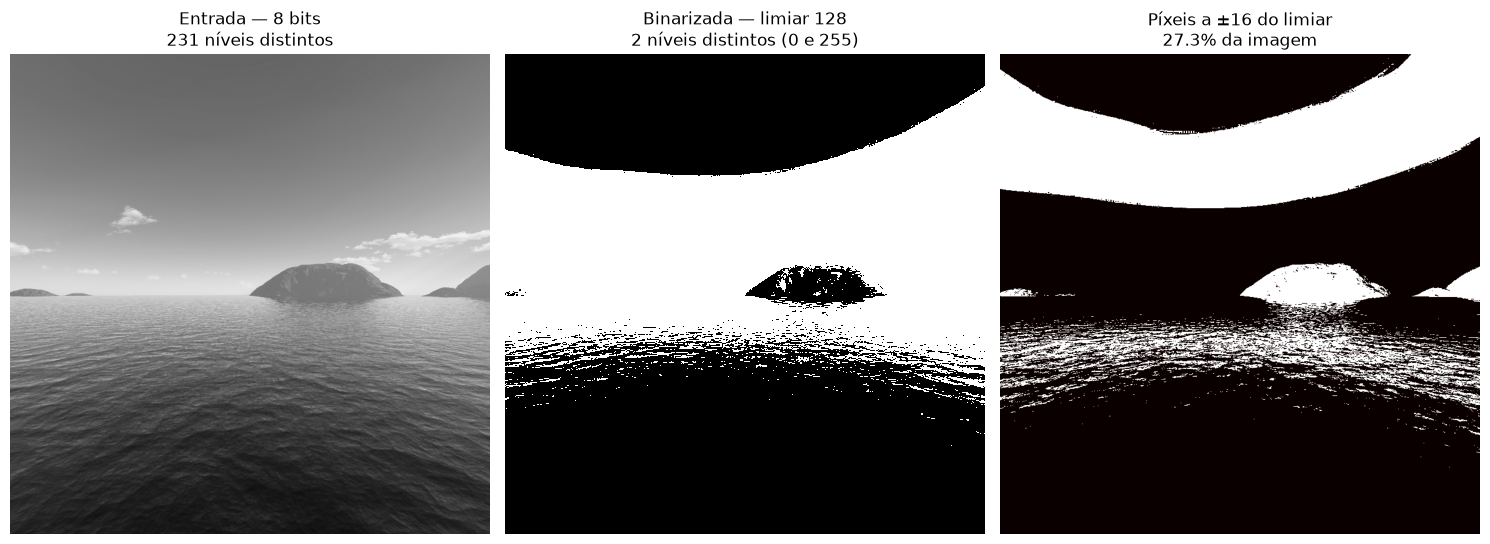

O painel à direita marca os píxeis cujo valor original estava próximo do
limiar. São os mais sensíveis: um pequeno deslocamento do limiar, ou um
pouco de ruído na aquisição, os jogaria para a outra classe.


In [7]:
# --- Comparação visual ---

fig, eixos = plt.subplots(1, 3, figsize=(15, 5.5))

eixos[0].imshow(original, cmap="gray", vmin=0, vmax=MAXVAL)
eixos[0].set_title(f"Entrada — 8 bits\n{np.unique(original).size} níveis distintos")

eixos[1].imshow(binarizada, cmap="gray", vmin=0, vmax=MAXVAL,
                interpolation="nearest")
eixos[1].set_title(f"Binarizada — limiar {LIMIAR}\n2 níveis distintos (0 e 255)")

# Onde a decisão foi mais "apertada": píxeis próximos da fronteira
margem = 16
fronteira = np.abs(original - LIMIAR) <= margem
eixos[2].imshow(fronteira, cmap="hot", vmin=0, vmax=1)
eixos[2].set_title(f"Píxeis a ±{margem} do limiar\n{fronteira.mean() * 100:.1f}% da imagem")

for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("O painel à direita marca os píxeis cujo valor original estava próximo do")
print("limiar. São os mais sensíveis: um pequeno deslocamento do limiar, ou um")
print("pouco de ruído na aquisição, os jogaria para a outra classe.")

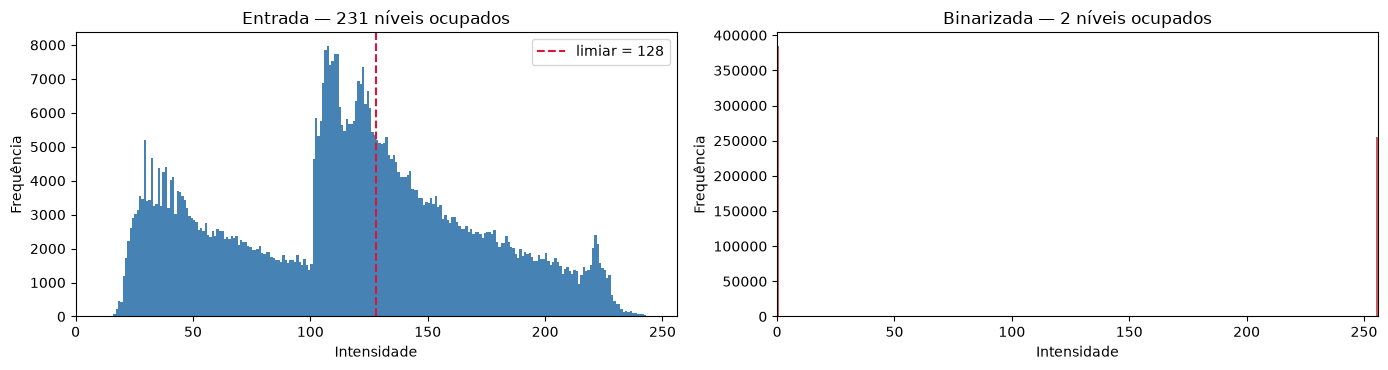

O histograma da saída tem exatamente duas raias, nos extremos da escala.
Toda a distribuição contínua da entrada foi colapsada nesses dois pontos:
é a assinatura de uma imagem binária gravada em formato de 8 bits.


In [8]:
# --- Histogramas: antes e depois ---

fig, eixos = plt.subplots(1, 2, figsize=(14, 3.8))

eixos[0].hist(original.ravel(), bins=256, range=(0, 256),
              color="steelblue", edgecolor="none")
eixos[0].axvline(LIMIAR, color="crimson", linestyle="--",
                 label=f"limiar = {LIMIAR}")
eixos[0].set_title(f"Entrada — {np.unique(original).size} níveis ocupados")
eixos[0].legend()

eixos[1].hist(binarizada.ravel(), bins=256, range=(0, 256),
              color="indianred", edgecolor="none")
eixos[1].set_title("Binarizada — 2 níveis ocupados")

for ax in eixos:
    ax.set_xlabel("Intensidade")
    ax.set_ylabel("Frequência")
    ax.set_xlim(0, 256)
plt.tight_layout()
plt.show()

print("O histograma da saída tem exatamente duas raias, nos extremos da escala.")
print("Toda a distribuição contínua da entrada foi colapsada nesses dois pontos:")
print("é a assinatura de uma imagem binária gravada em formato de 8 bits.")

## 3. O custo de gravar conteúdo binário em formato de 8 bits

O arquivo produzido carrega 1 bit de informação real por píxel — a resposta a
"claro ou escuro?" — mas o formato reserva espaço para 8. Vale medir o
desperdício em três representações:

| Representação | Espaço por píxel | Observação |
|---------------|------------------|------------|
| PGM P2 (esta saída) | 2 a 4 caracteres | `"0 "` ou `"255 "` |
| PGM P5 (binário) | 1 byte | `maxval` continua 255 |
| PBM P4 (binário) | 1 bit | o formato adequado ao conteúdo |

A célula seguinte quantifica isso. Vale notar que a saída binarizada ocupa
**menos** espaço em ASCII que a entrada — não por eficiência de codificação, mas
porque `"0"` tem um caractere e a maioria dos valores da entrada tinha três.

Há um ponto mais interessante: como o conteúdo é altamente repetitivo, esta é
exatamente a situação que a apostila descreve como favorável ao **RLE**, em que
"grandes grupos de píxeis consecutivos apresentam a mesma cor". A célula estima
o ganho que um RLE simples obteria — em oposição direta ao caso do ruído
aleatório da primeira atividade, onde nenhum algoritmo de compressão ajudaria.

In [9]:
# --- Análise de espaço ocupado ---

n_px = binarizada.size

tam_entrada = ARQUIVO_ENTRADA.stat().st_size
tam_saida = ARQUIVO_SAIDA.stat().st_size
tam_p5 = n_px                  # 1 byte por píxel
tam_p4 = n_px / 8              # 1 bit por píxel
info_real = n_px / 8           # 1 bit de informação por píxel

print(f"{'Representação':<34}{'Bytes':>14}{'vs. informação':>17}")
print("-" * 65)
for nome, tam in [
    (f"Entrada P2 (8 bits reais)", tam_entrada),
    (f"Saída P2 ASCII (esta atividade)", tam_saida),
    (f"Mesma imagem em P5 (binário)", tam_p5),
    (f"Mesma imagem em P4 / PBM binário", tam_p4),
    (f"Informação real contida", info_real),
]:
    print(f"{nome:<34}{tam:>14,.0f}{tam / info_real:>16.1f}x")

print()
print(f"Redução da entrada para a saída: "
      f"{(1 - tam_saida / tam_entrada) * 100:.1f}%")
print(f"A saída P2 ocupa {tam_saida / tam_p4:.0f} vezes o espaço que o mesmo")
print(f"conteúdo ocuparia em PBM binário.")

# Estimativa de compressão RLE sobre o varrimento linha a linha
plano = binarizada.reshape(-1)
mudancas = int((plano[1:] != plano[:-1]).sum()) + 1
print()
print(f"Sequências (runs) no varrimento : {mudancas:,}")
print(f"Comprimento médio de sequência  : {n_px / mudancas:.1f} píxeis")
print(f"Estimativa RLE (2 bytes/run)    : {mudancas * 2:,} bytes")
print(f"Fator de compressão estimado    : {tam_p5 / (mudancas * 2):.1f}x sobre o P5")

Representação                              Bytes   vs. informação
-----------------------------------------------------------------
Entrada P2 (8 bits reais)              2,994,160            37.4x
Saída P2 ASCII (esta atividade)        1,790,362            22.4x
Mesma imagem em P5 (binário)             640,000             8.0x
Mesma imagem em P4 / PBM binário          80,000             1.0x
Informação real contida                   80,000             1.0x

Redução da entrada para a saída: 40.2%
A saída P2 ocupa 22 vezes o espaço que o mesmo
conteúdo ocuparia em PBM binário.

Sequências (runs) no varrimento : 7,933
Comprimento médio de sequência  : 80.7 píxeis
Estimativa RLE (2 bytes/run)    : 15,866 bytes
Fator de compressão estimado    : 40.3x sobre o P5


## 4. Comparação com a atividade anterior

Vale confrontar diretamente as duas saídas para confirmar que a **decisão** é a
mesma e só a **codificação** difere.

Se a atividade 05-2 estiver disponível, a célula abaixo verifica a equivalência.
A correspondência esperada é:

    PBM: 0 <-> PGM: 0     (preto)
    PBM: 1 <-> PGM: 255   (branco)

Formalmente, a saída em PBM multiplicada por 255 deve reproduzir exatamente a
saída em PGM. Se isso se confirmar, está demonstrado que as duas atividades
aplicam a mesma transformação e diferem apenas no formato de destino.

*A célula é ignorada sem erro caso o arquivo não seja encontrado.*

In [10]:
# --- Equivalência com a saída PBM da atividade 05-2 ---

ARQUIVO_PBM = ENTRADA / "a_binarizada_limiar128.pbm"

if ARQUIVO_PBM.exists():
    with open(ARQUIVO_PBM, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)
        magic = next(it)
        larg_p1, alt_p1 = (int(next(it)) for _ in range(2))   # P1 não tem maxval
        pbm = np.fromiter(map(int, it), dtype=np.int32,
                          count=larg_p1 * alt_p1).reshape(alt_p1, larg_p1)

    equivalente = np.array_equal(pbm * MAXVAL, binarizada)

    print(f"Arquivo PBM       : {ARQUIVO_PBM.name} (magic {magic})")
    print(f"Valores no PBM    : {sorted(np.unique(pbm).tolist())}")
    print(f"Valores no PGM    : {sorted(np.unique(binarizada).tolist())}")
    print(f"PBM x 255 == PGM  : {equivalente}")
    print()
    if equivalente:
        print("Confirmado: as duas atividades aplicam a mesma decisão de")
        print("binarização. A diferença está inteiramente na codificação do")
        print("branco — 1 no PBM, 255 no PGM — e no formato do arquivo.")
else:
    print(f"Arquivo {ARQUIVO_PBM.name} não encontrado.")
    print("Copie a saída da atividade 05-2 para a pasta 'entrada' para")
    print("habilitar esta comparação.")

Arquivo a_binarizada_limiar128.pbm não encontrado.
Copie a saída da atividade 05-2 para a pasta 'entrada' para
habilitar esta comparação.


  limiar     % preto    % branco
--------------------------------
      64      21.92%      78.08%
      96      31.45%      68.55%
     112      45.05%      54.95%
     128      60.14%      39.86%
     144      71.36%      28.64%
     176      85.88%      14.12%
     208      95.16%       4.84%
     232      99.84%       0.16%


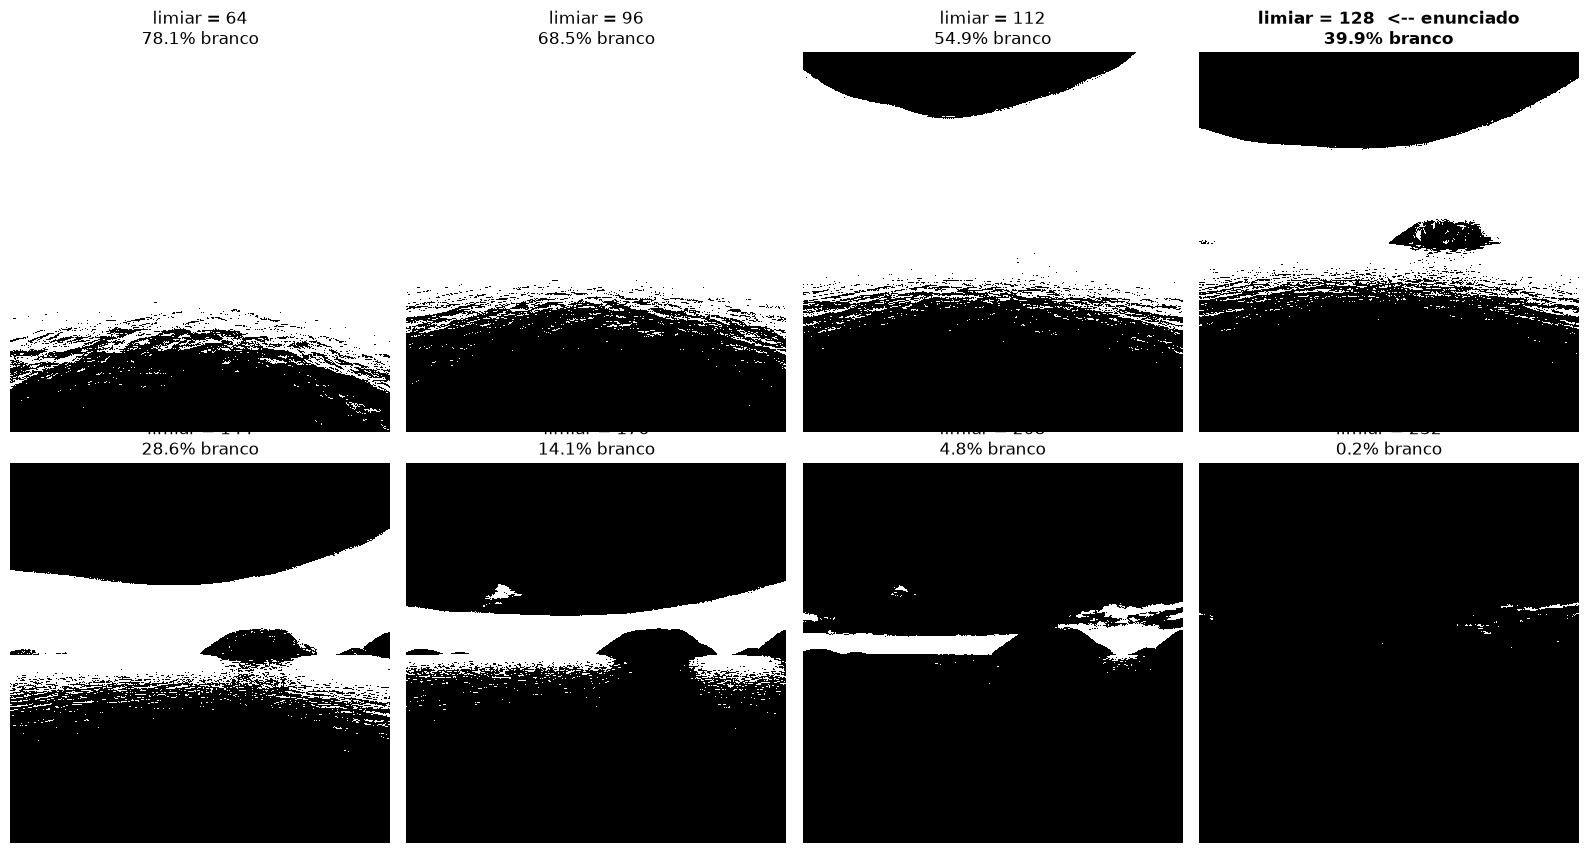


A proporção de branco cai monotonicamente conforme o limiar sobe.
Cada valor de limiar preserva um conjunto diferente de estruturas da
imagem — não existe um limiar universalmente correto, apenas o mais
adequado ao que se pretende extrair.


In [11]:
# --- Bônus: sensibilidade ao limiar ---

limiares = [64, 96, 112, 128, 144, 176, 208, 232]
fig, eixos = plt.subplots(2, 4, figsize=(16, 8.5))

print(f"{'limiar':>8}{'% preto':>12}{'% branco':>12}")
print("-" * 32)

for ax, t in zip(eixos.ravel(), limiares):
    b = binarizar_pgm(original, limiar=t)
    pct_branco = (b == BRANCO).mean() * 100

    ax.imshow(b, cmap="gray", vmin=0, vmax=MAXVAL, interpolation="nearest")
    destaque = "  <-- enunciado" if t == LIMIAR else ""
    ax.set_title(f"limiar = {t}{destaque}\n{pct_branco:.1f}% branco",
                 fontweight="bold" if t == LIMIAR else "normal")
    ax.axis("off")

    print(f"{t:>8}{100 - pct_branco:>11.2f}%{pct_branco:>11.2f}%")

plt.tight_layout()
plt.show()

print()
print("A proporção de branco cai monotonicamente conforme o limiar sobe.")
print("Cada valor de limiar preserva um conjunto diferente de estruturas da")
print("imagem — não existe um limiar universalmente correto, apenas o mais")
print("adequado ao que se pretende extrair.")

---

## Conclusões

### Resultado

O arquivo `saida/Saida_binarizada_P2_limiar128.pgm` foi gerado em PGM P2, com
`maxval = 255`, contendo exclusivamente os valores 0 e 255 — verificado por
inspeção do arquivo já relido do disco, e não apenas do array em memória.

Validações realizadas:

1. Cálculo direto e aplicação via LUT produzem resultados idênticos, confirmando
   que a transformação é pontual.
2. Round-trip de escrita e leitura sem divergências.
3. O conjunto de valores presentes no arquivo é exatamente `{0, 255}`.
4. Nenhuma linha excede 70 caracteres.

### A diferença que o enunciado destaca

O professor chama atenção para a similaridade com a atividade anterior, e ela é
real: a decisão de binarização é idêntica. O que muda é onde essa decisão é
gravada.

Em PBM, o branco é o bit `1` — o formato não tem `maxval` e a intensidade é
implícita. Em PGM, o branco é o valor `maxval` declarado no cabeçalho. Gravar
`1` num PGM de `maxval = 255` não daria branco, daria um cinza praticamente
indistinguível do preto. A codificação de uma classe depende da capacidade do
formato que a hospeda.

### Custo e benefício da escolha

O arquivo carrega 1 bit de informação por píxel em um formato que reserva 8 —
e, sendo ASCII, gasta ainda mais. Em PBM binário, o mesmo conteúdo caberia numa
fração do espaço.

O que se ganha em troca é ausência de ambiguidade. Na atividade anterior, o
conflito entre a especificação oficial do PBM (`1` = preto) e a convenção da
apostila (`1` = branco) fazia o mesmo arquivo aparecer invertido conforme o
visualizador. Em PGM não há divergência: 0 é preto e `maxval` é branco, ponto.
Para um arquivo destinado a inspeção humana ou a interoperar com ferramentas
diversas, essa previsibilidade costuma valer mais que o espaço economizado.

### Sobre a compressão

A análise de sequências mostra que esta imagem é o caso favorável ao RLE que a
apostila descreve: longas corridas de píxeis de mesma cor, exatamente o que
aquele algoritmo explora. É o oposto do ruído aleatório gerado na primeira
atividade, onde nenhuma família de compressão obteria ganho — a natureza do
conteúdo, e não o formato, é o que determina qual algoritmo funciona.